In [1]:
import logging
import asyncio
from functools import partial
from langgraph.graph import StateGraph, END

from agent_state import AgentState
from agent_nodes import (
    intent_classifier_node, orchestrator_node,
    repo_analyst_node, code_analyst_node, pr_node,
    issues_node, team_node, security_node, copilot_node,
    write_ops_node, meta_node, synthesizer_node, get_llm
)

logger = logging.getLogger(__name__)


def router_edge(state: dict) -> str:
    if state.get("needs_clarification"):
        logger.info("[ROUTER] → clarify (needs clarification)")
        return "synthesizer"
    if state.get("is_complete"):
        logger.info("[ROUTER] → synthesizer (is_complete=True)")
        return "synthesizer"

    next_node = state.get("next_node", "synthesizer")
    valid_nodes = [
        "repo_analyst", "code_analyst", "pr_node",
        "issues_node", "team_node", "security_node",
        "copilot_node", "write_ops", "meta_node", "synthesizer"
    ]

    if next_node not in valid_nodes:
        logger.warning(f"[ROUTER] Invalid next_node '{next_node}' → defaulting to synthesizer")
        return "synthesizer"

    logger.info(f"[ROUTER] → {next_node}")
    return next_node


def build_graph(azure_endpoint, azure_api_key, deployment_name, api_version, all_tools):
    logger.info("[GRAPH] Building LangGraph agent...")

    llm = get_llm(azure_endpoint, azure_api_key, deployment_name, api_version)

    # Wrap async nodes with partial for dependency injection
    intent_node    = partial(intent_classifier_node, llm=llm)
    orch_node      = partial(orchestrator_node, llm=llm)
    repo_node      = partial(repo_analyst_node, llm=llm, all_tools=all_tools)
    code_node      = partial(code_analyst_node, llm=llm, all_tools=all_tools)
    pr_node_fn     = partial(pr_node, llm=llm, all_tools=all_tools)
    issues_node_fn = partial(issues_node, llm=llm, all_tools=all_tools)
    team_node_fn   = partial(team_node, llm=llm, all_tools=all_tools)
    sec_node       = partial(security_node, llm=llm, all_tools=all_tools)
    cop_node       = partial(copilot_node, llm=llm, all_tools=all_tools)
    write_node     = partial(write_ops_node, llm=llm, all_tools=all_tools)
    meta_node_fn   = partial(meta_node, llm=llm, all_tools=all_tools)
    synth_node     = partial(synthesizer_node, llm=llm)

    graph = StateGraph(AgentState)

    graph.add_node("intent_classifier", intent_node)
    graph.add_node("orchestrator",      orch_node)
    graph.add_node("repo_analyst",      repo_node)
    graph.add_node("code_analyst",      code_node)
    graph.add_node("pr_node",           pr_node_fn)
    graph.add_node("issues_node",       issues_node_fn)
    graph.add_node("team_node",         team_node_fn)
    graph.add_node("security_node",     sec_node)
    graph.add_node("copilot_node",      cop_node)
    graph.add_node("write_ops",         write_node)
    graph.add_node("meta_node",         meta_node_fn)
    graph.add_node("synthesizer",       synth_node)

    graph.set_entry_point("intent_classifier")
    graph.add_edge("intent_classifier", "orchestrator")

    graph.add_conditional_edges(
        "orchestrator",
        router_edge,
        {
            "repo_analyst":  "repo_analyst",
            "code_analyst":  "code_analyst",
            "pr_node":       "pr_node",
            "issues_node":   "issues_node",
            "team_node":     "team_node",
            "security_node": "security_node",
            "copilot_node":  "copilot_node",
            "write_ops":     "write_ops",
            "meta_node":     "meta_node",
            "synthesizer":   "synthesizer",
        }
    )

    # All specialist nodes loop back to orchestrator
    for node_name in [
        "repo_analyst", "code_analyst", "pr_node",
        "issues_node", "team_node", "security_node",
        "copilot_node", "write_ops", "meta_node"
    ]:
        graph.add_edge(node_name, "orchestrator")

    graph.add_edge("synthesizer", END)

    compiled = graph.compile()
    logger.info("[GRAPH] Graph compiled successfully")
    return compiled


async def run_query_async(graph, user_query, repo_owner, repo_name) -> str:
    logger.info(f"[RUN] Starting query: '{user_query}' on {repo_owner}/{repo_name}")

    initial_state = {
        "user_query": user_query,
        "repo_owner": repo_owner,
        "repo_name": repo_name,
        "messages": [],
        "intermediate_results": {},
        "tool_calls_made": [],
        "loop_count": 0,
        "is_complete": False,
        "needs_clarification": False,
        "plan": [],
        "current_step": 0,
        "next_node": "",
        "intent": "",
        "domain": [],
        "final_answer": "",
        "error": None
    }

    result = await graph.ainvoke(initial_state)
    logger.info(f"[RUN] Query complete. Answer length: {len(result.get('final_answer', ''))}")
    return result.get("final_answer", "No answer generated.")


def run_query(graph, user_query, repo_owner, repo_name) -> str:
    """Sync wrapper — runs async graph in event loop."""
    return asyncio.run(run_query_async(graph, user_query, repo_owner, repo_name))

In [2]:
sampel = build_graph(
    azure_endpoint="https://your-azure-endpoint.openai.azure.com/",
    azure_api_key="your-azure-api-key",
    deployment_name="your-deployment-name",
    api_version="2024-06-01",
    all_tools=["list_repos", "read_file", "list_prs", "list_issues", "get_team_info", "check_security", "copilot_suggest", "write_file"]
)

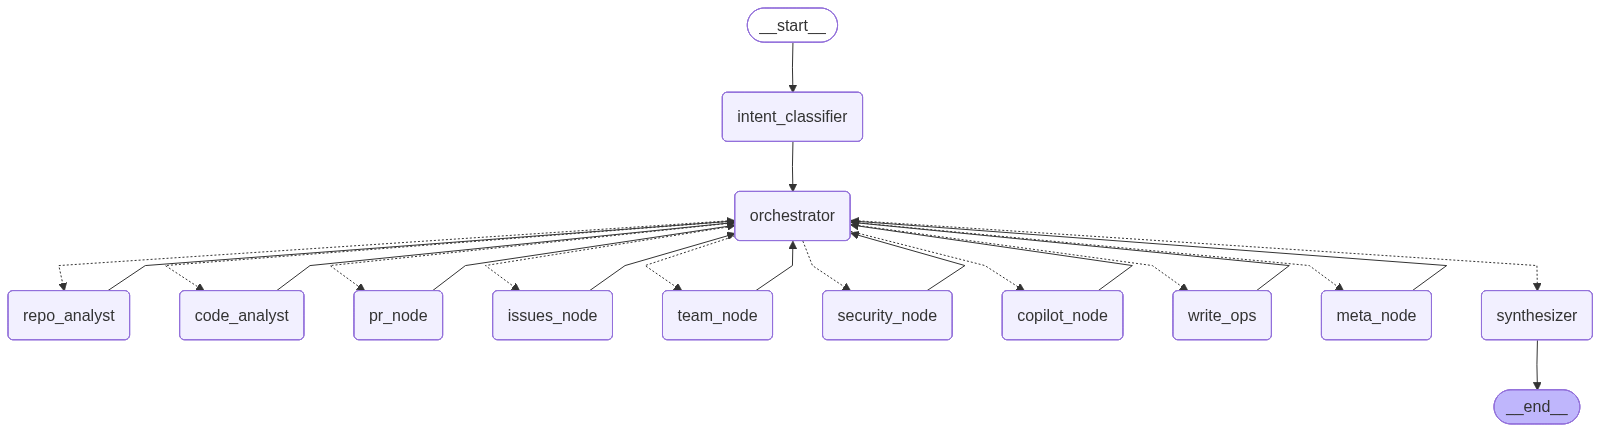

In [3]:
sampel

In [4]:
import time

def download_file(name):
    print(f"Start downloading {name}")
    time.sleep(2)  # simulate network delay
    print(f"Finished downloading {name}")

def main():
    start = time.time()

    download_file("File 1")
    download_file("File 2")
    download_file("File 3")

    end = time.time()
    print(f"Total time: {end - start:.2f} seconds")

main()

Start downloading File 1
Finished downloading File 1
Start downloading File 2
Finished downloading File 2
Start downloading File 3
Finished downloading File 3
Total time: 6.01 seconds


In [6]:
import asyncio
import time

async def download_file(name):
    print(f"Start downloading {name}")
    await asyncio.sleep(2)  # simulate network delay
    print(f"Finished downloading {name}")

async def main():
    start = time.time()

    await asyncio.gather(
        download_file("File 1"),
        download_file("File 2"),
        download_file("File 3")
    )

    end = time.time()
    print(f"Total time: {end - start:.2f} seconds")

await main()

Start downloading File 1
Start downloading File 2
Start downloading File 3
Finished downloading File 1
Finished downloading File 2
Finished downloading File 3
Total time: 2.03 seconds
